In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'unemployment-in-india' dataset.
Path to dataset files: /kaggle/input/unemployment-in-india


Importing the libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Reading the csv *file*

In [12]:
df = pd.read_csv("/kaggle/input/unemployment-in-india/Unemployment in India.csv")
df_2020 = pd.read_csv("/kaggle/input/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv")

Understanding the data

In [13]:
df.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,31-10-2019,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,30-11-2019,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,31-12-2019,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,31-01-2020,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,29-02-2020,Monthly,5.91,11723617.0,42.83,Rural


In [14]:
df_2020.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74
5,Andhra Pradesh,30-06-2020,M,3.31,19805400,47.41,South,15.9129,79.74
6,Andhra Pradesh,31-07-2020,M,8.34,15431615,38.91,South,15.9129,79.74
7,Andhra Pradesh,31-08-2020,M,6.96,15251776,37.83,South,15.9129,79.74
8,Andhra Pradesh,30-09-2020,M,6.40,15220312,37.47,South,15.9129,79.74
9,Andhra Pradesh,31-10-2020,M,6.59,15157557,37.34,South,15.9129,79.74


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [16]:
df_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [17]:
df.shape

(768, 7)

In [18]:
df_2020.shape

(267, 9)

Data Cleaning

In [19]:
#Removing the Extra spaces between the columns

df.columns = df.columns.str.strip()
df_2020.columns = df_2020.columns.str.strip()

In [20]:
df.columns
df_2020.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [21]:
#checking for missing values in df
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [22]:
#checking for missing values in df_2020
df_2020.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Region.1,0
longitude,0
latitude,0


In [23]:
df = df.dropna()
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [24]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [25]:
df[df['Estimated Unemployment Rate (%)'] == 0]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
25,Assam,30-06-2020,Monthly,0.0,7544937.0,34.38,Rural
51,Chhattisgarh,30-04-2020,Monthly,0.0,6534321.0,39.43,Rural
77,Goa,29-02-2020,Monthly,0.0,171672.0,36.11,Rural
231,Puducherry,31-05-2019,Monthly,0.0,172474.0,43.08,Rural
232,Puducherry,30-06-2019,Monthly,0.0,184527.0,45.95,Rural
233,Puducherry,31-07-2019,Monthly,0.0,139227.0,34.56,Rural
235,Puducherry,30-09-2019,Monthly,0.0,175718.0,43.34,Rural
237,Puducherry,30-11-2019,Monthly,0.0,142787.0,35.00,Rural
274,Sikkim,30-04-2020,Monthly,0.0,133399.0,37.72,Rural
617,Puducherry,30-06-2019,Monthly,0.0,304369.0,37.73,Urban


EXPLORATORY DATA ANALYSIS

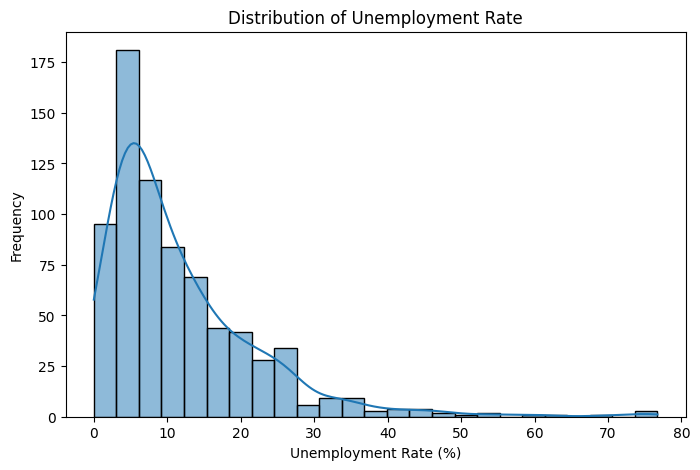

In [26]:
#checking the distribuution of unemployment rate
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated Unemployment Rate (%)'],bins = 25,kde = True)
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()

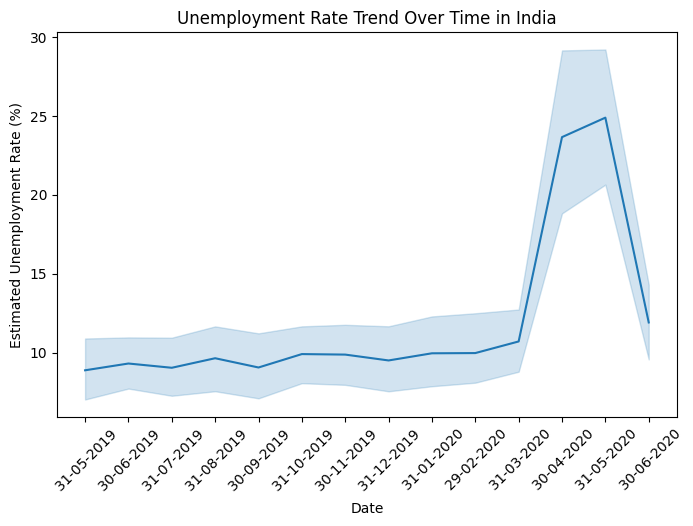

In [27]:

#unemployment trend over the time
plt.figure(figsize=(8,5))
sns.lineplot(x= 'Date',y = 'Estimated Unemployment Rate (%)', data=df)
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.title("Unemployment Rate Trend Over Time in India")
plt.show()

In [28]:
#Region-wise Unemployment
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

region_avg.head(10)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


Text(0, 0.5, 'estimated un rate')

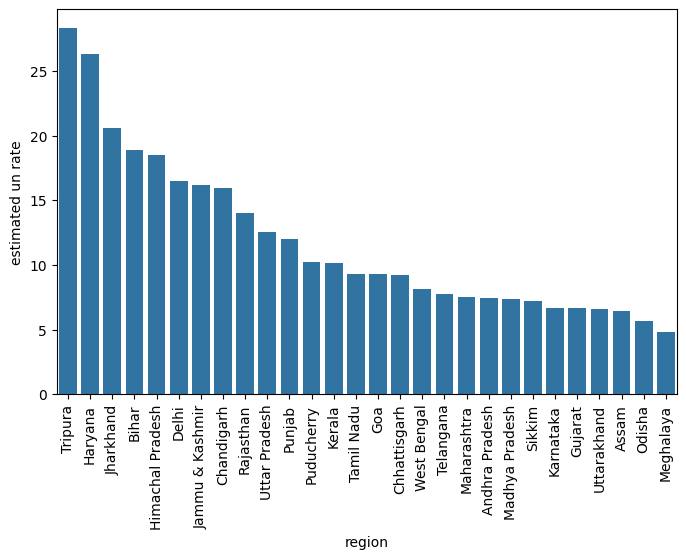

In [35]:
#Visualising Region-wise Unemployment
plt.figure(figsize = (8,5))
sns.barplot(x = region_avg.index,y = region_avg.values )
plt.xticks(rotation = 90)
plt.xlabel('region')
plt.ylabel('estimated un rate')


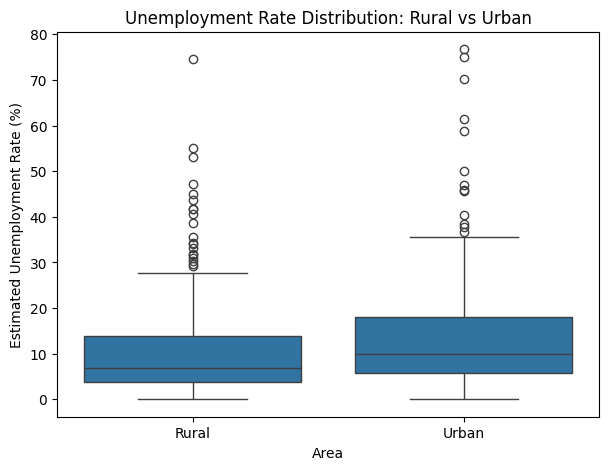

In [36]:
#rural vs urban
plt.figure(figsize=(7,5))

sns.boxplot(x='Area', y='Estimated Unemployment Rate (%)', data=df)

plt.title("Unemployment Rate Distribution: Rural vs Urban")

plt.show()

In [41]:
df.corr(numeric_only= True)

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


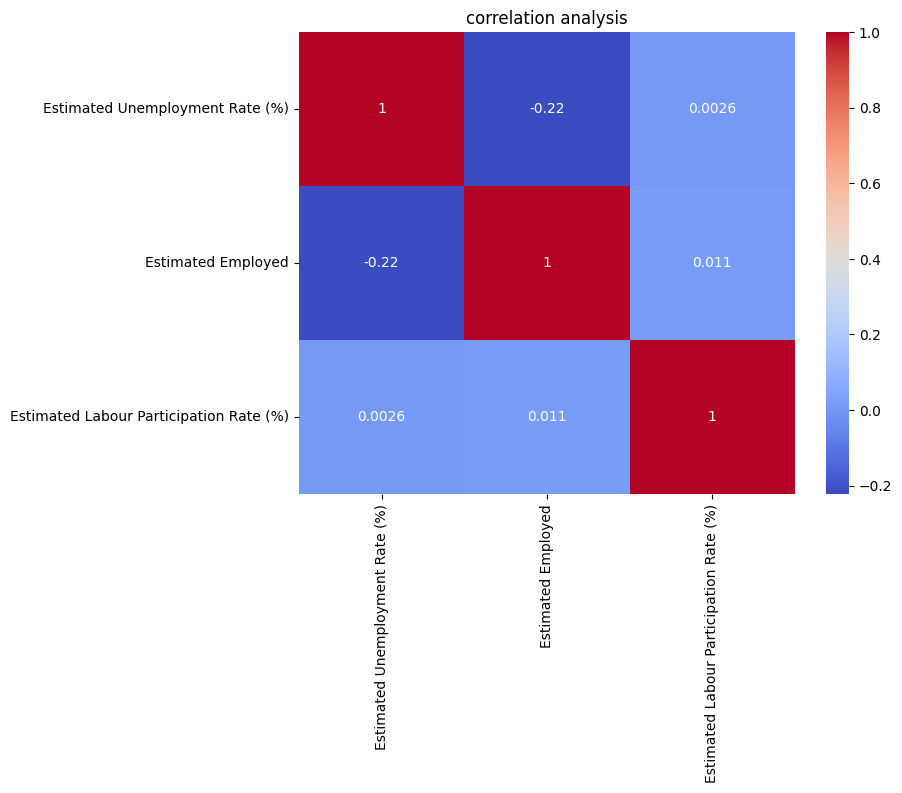

In [38]:
#correlation analysis
plt.figure(figsize = (8,6))
sns.heatmap((df.corr(numeric_only= True)),annot= True,cmap = "coolwarm")
plt.title('correlation analysis')
plt.show()

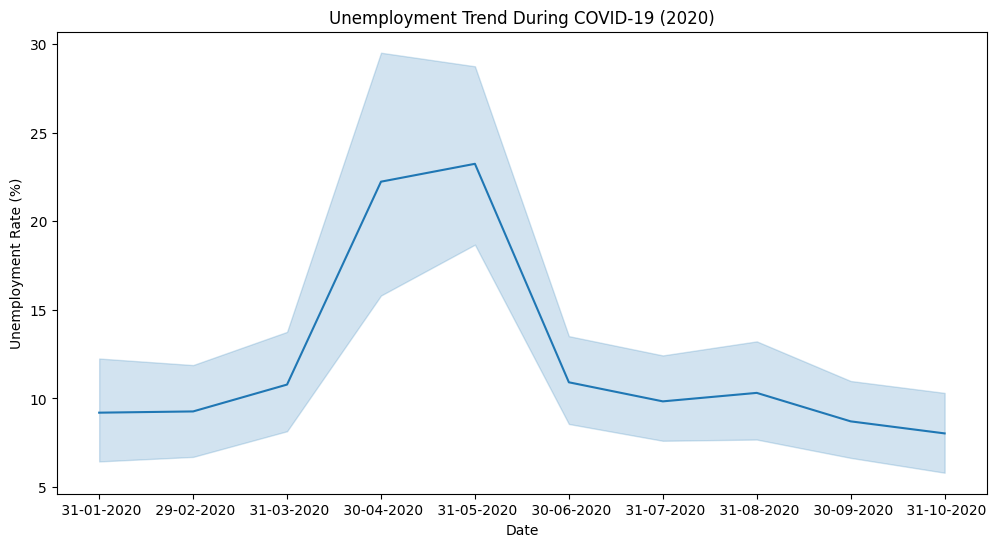

In [42]:
#COVID Impact Analysis
plt.figure(figsize=(12,6))

sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=df_2020)

plt.title("Unemployment Trend During COVID-19 (2020)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.show()